# **NLP Final Project**

Link to Project folder that includes original and exported datasets: https://drive.google.com/drive/folders/1ob8WJKSEhmVp7xzHRtqgrbA6hiEeLtLF?usp=sharing 

## **Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = '/content/drive/MyDrive/NLP Project/'

DTYPE_SPEC = {
    'author_id': str}

Load and concat all review tables

In [ ]:
import pandas as pd
import re


# Read each review file separately
df1 = pd.read_csv(BASE_PATH + 'reviews_0-250.csv', dtype=DTYPE_SPEC, encoding='utf-8')
df2 = pd.read_csv(BASE_PATH + 'reviews_250-500.csv', dtype=DTYPE_SPEC, encoding='utf-8')
df3 = pd.read_csv(BASE_PATH + 'reviews_500-750.csv', dtype=DTYPE_SPEC, encoding='utf-8')
df4 = pd.read_csv(BASE_PATH + 'reviews_750-1250.csv', dtype=DTYPE_SPEC, encoding='utf-8')
df5 = pd.read_csv(BASE_PATH + 'reviews_1250-end.csv', dtype=DTYPE_SPEC, encoding='utf-8')

df_all = pd.concat([df1,df2,df3,df4,df5], ignore_index=True)

# Force dtype conversion to reduce memory usage
df_all['brand_name'] = df_all['brand_name'].astype('category')
df_all['author_id']  = df_all['author_id'].astype('str')
for col in ['skin_tone', 'eye_color', 'skin_type', 'hair_color']:
    df_all[col] = df_all[col].astype('category')

print(df_all.dtypes)
print(df_all.memory_usage(deep=True).sum() / 1024**2, "MB")

Unnamed: 0                     int64
author_id                     object
rating                         int64
is_recommended               float64
helpfulness                  float64
total_feedback_count           int64
total_neg_feedback_count       int64
total_pos_feedback_count       int64
submission_time               object
review_text                   object
review_title                  object
skin_tone                   category
eye_color                   category
skin_type                   category
hair_color                  category
product_id                    object
product_name                  object
brand_name                  category
price_usd                    float64
dtype: object
1056.8044004440308 MB


Load product table

In [ ]:
import pandas as pd
import re
df_product = pd.read_csv(BASE_PATH + 'product_info.csv', dtype=DTYPE_SPEC, encoding='utf-8')

#**Data Preprocessing**

###**Review tables**  
This dataset focus purely on Skincare reviews -> focus on tertiary category, not primary category (primary category is skincare)

In [ ]:
review = df_all.copy()
review.head()
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype   
---  ------                    --------------    -----   
 0   Unnamed: 0                1094411 non-null  int64   
 1   author_id                 1094411 non-null  object  
 2   rating                    1094411 non-null  int64   
 3   is_recommended            926423 non-null   float64 
 4   helpfulness               532819 non-null   float64 
 5   total_feedback_count      1094411 non-null  int64   
 6   total_neg_feedback_count  1094411 non-null  int64   
 7   total_pos_feedback_count  1094411 non-null  int64   
 8   submission_time           1094411 non-null  object  
 9   review_text               1092967 non-null  object  
 10  review_title              783757 non-null   object  
 11  skin_tone                 923872 non-null   category
 12  eye_color                 884783 non-null   category
 13  skin_type   

In [ ]:
#Drop unnecessary columns to reduce RAM/df size

cols_to_drop = [
    'Unnamed: 0',
    'helpfulness',
    'total_feedback_count',
    'total_pos_feedback_count',
    'total_neg_feedback_count',
]
review = review.drop(columns=[c for c in cols_to_drop if c in review.columns])

In [ ]:
import re
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt_tab', quiet=True)

def clean_df(df):
    """
    Basic cleaning + prepare text for both VADER and ABSA pipelines.
    VADER: keep raw text (preserve caps, punctuation, negations).
    ABSA:  lowercase + remove punctuation for keyword matching.
    """
    # Drop rows with null review_text
    df = df.dropna(subset=['review_text']).copy()

    # Ensure all values are strings (extra safety against non-string floats)
    df = df[df['review_text'].apply(lambda x: isinstance(x, str))].copy()

    # VADER pipeline: keep raw text, only strip whitespace
    df['review_text_vader'] = df['review_text'].str.strip()

    # Drop rows where text becomes empty after stripping
    df = df[df['review_text_vader'] != ''].copy()

    # ABSA pipeline: lowercase + remove punctuation for keyword matching
    df['clean_text_absa'] = (
        df['review_text']
          .str.lower()
          .str.strip()
          .apply(lambda x: re.sub(r'[^\w\s]', '', x))
    )

    # Split raw review into sentences (reused by document-level VADER and ABSA)
    df['sentences'] = df['review_text_vader'].apply(sent_tokenize)

    return df


In [ ]:
review = clean_df(review)

In [ ]:
# Verify
print(f"Rows: {len(review):,}")
print(f"New columns: {[c for c in review.columns if c.endswith('_vader') or c.endswith('_absa') or c == 'sentences']}")

Rows: 1,092,967
New columns: ['review_text_vader', 'clean_text_absa', 'sentences']


In [ ]:
#reviews['tokens'] = reviews['clean_text'].apply(lambda x: x.split())

In [ ]:
review.head()

,author_id,rating,is_recommended,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,review_text_vader,clean_text_absa,sentences
0,1741593524,5,1.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,I use this with the Nudestix “Citrus Clean Bal...,i use this with the nudestix citrus clean balm...,[I use this with the Nudestix “Citrus Clean Ba...
1,31423088263,1,0.0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I bought this lip mask after reading the revie...,i bought this lip mask after reading the revie...,[I bought this lip mask after reading the revi...
2,5061282401,5,1.0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,My review title says it all! I get so excited ...,my review title says it all i get so excited t...,"[My review title says it all!, I get so excite..."
3,6083038851,5,1.0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I’ve always loved this formula for a long time...,ive always loved this formula for a long time ...,[I’ve always loved this formula for a long tim...
4,47056667835,5,1.0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"If you have dry cracked lips, this is a must h...",if you have dry cracked lips this is a must ha...,"[If you have dry cracked lips, this is a must ..."


In [ ]:
review.isnull().sum()

,0
author_id,0
rating,0
is_recommended,167988
submission_time,0
review_text,0
review_title,309210
skin_tone,170499
eye_color,209566
skin_type,111518
hair_color,226718


One-time save

In [ ]:
#One-time save only
#review.to_csv('clean_reviews.csv', index=False)

Load the saved file

In [ ]:
review = pd.read_csv(BASE_PATH + 'clean_reviews.csv', dtype=DTYPE_SPEC, encoding='utf-8')

In [ ]:
import ast
#because after saved as csv, type of this column changed to string -> convert back to list of sentences
review['sentences'] = review['sentences'].apply(ast.literal_eval)

###**Product Table**

In [ ]:
#print(df_product.shape)
print(df_product.columns.tolist())



['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


In [ ]:
# Only join the 3 category columns
cols_to_join = ['product_id',
                'tertiary_category']

review = review.merge(
    df_product[cols_to_join],
    on='product_id',
    how='left')

# Verify
review.head()
print(f"Null count: {review['tertiary_category'].isna().sum()}")


Null count: 161006


In [ ]:
print(type(review['sentences'].iloc[0]))
print(review['sentences'].iloc[0][:2])

<class 'list'>
['I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better).', 'The make-up melt is oil based and removes all of your makeup super easily.']


In [ ]:
review.head()

,author_id,rating,is_recommended,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,review_text_vader,clean_text_absa,sentences,tertiary_category
0,1741593524,5,1.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,I use this with the Nudestix “Citrus Clean Bal...,i use this with the nudestix citrus clean balm...,[I use this with the Nudestix “Citrus Clean Ba...,NaN
1,31423088263,1,0.0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I bought this lip mask after reading the revie...,i bought this lip mask after reading the revie...,[I bought this lip mask after reading the revi...,NaN
2,5061282401,5,1.0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,My review title says it all! I get so excited ...,my review title says it all i get so excited t...,"[My review title says it all!, I get so excite...",NaN
3,6083038851,5,1.0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I’ve always loved this formula for a long time...,ive always loved this formula for a long time ...,[I’ve always loved this formula for a long tim...,NaN
4,47056667835,5,1.0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"If you have dry cracked lips, this is a must h...",if you have dry cracked lips this is a must ha...,"[If you have dry cracked lips, this is a must ...",NaN


# **EDA**

Show distribution of star ratings in 5 tables  
Show distribution of length of review text  
Top 10 brands has most reviews  (check number of reviews)
Heatmap top 10 brands x star ratings (check to see if the top 10 brands with most reviews has high or low  star ratings)


Star distribution across all reviews -> Rationale for the adjusted scale   
4-5 positive, 3 neutral, 1-2 negative

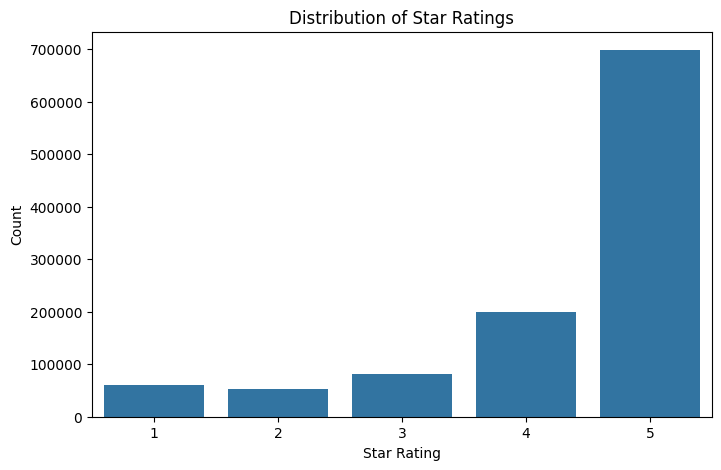

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Star rating distribution
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=review)

plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Count")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute word-level length
review['review_length_words'] = review['review_text_vader'].str.split().str.len()

# Descriptive stats
print("=== Review length (words) ===")
print(review['review_length_words'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
))

=== Review length (words) ===
count    1.092967e+06
mean     6.053948e+01
std      4.348206e+01
min      1.000000e+00
10%      1.900000e+01
25%      3.200000e+01
50%      5.000000e+01
75%      7.600000e+01
90%      1.120000e+02
95%      1.420000e+02
99%      2.220000e+02
max      1.216000e+03
Name: review_length_words, dtype: float64


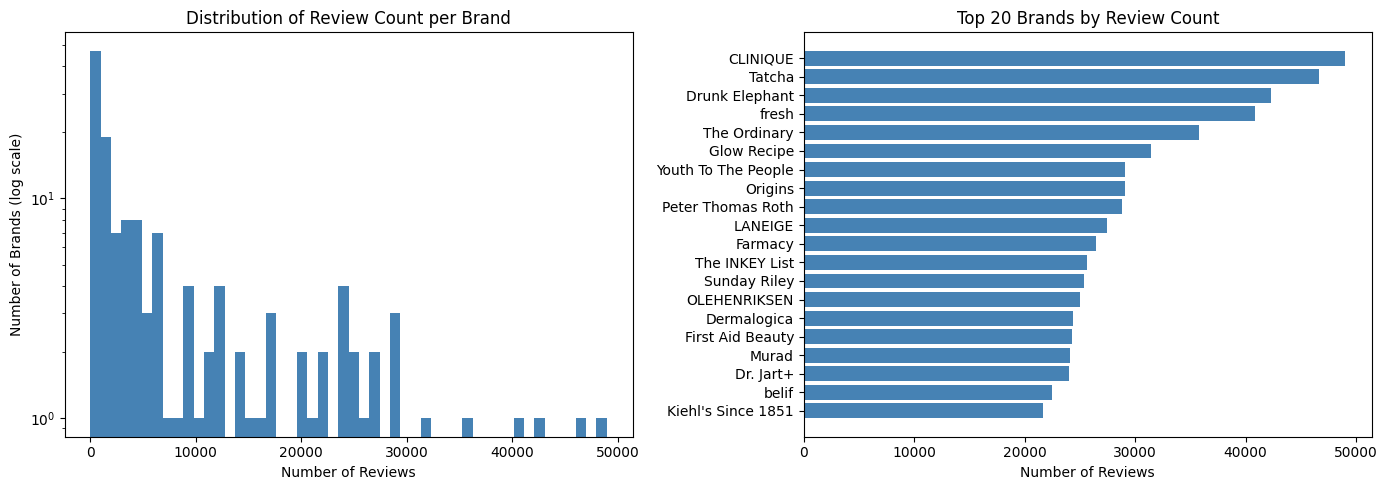

count      142.0
mean      7697.0
std      10740.0
min          2.0
25%        499.0
50%       2362.0
75%      10962.0
90%      24395.0
95%      29031.0
max      48977.0
Name: count, dtype: float64


In [ ]:
# Number of reviews distribution per brand
brand_review_count = (
    review.groupby('brand_name')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of review counts across all brands
axes[0].hist(brand_review_count['count'], bins=50, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Review Count per Brand')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Brands (log scale)')

# Plot 2: Top 20 brands by review count
top20 = brand_review_count.head(20)
axes[1].barh(top20['brand_name'].astype(str), top20['count'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Brands by Review Count')
axes[1].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

# Summary stats
print(brand_review_count['count'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
).round(0))


Check review length distribution

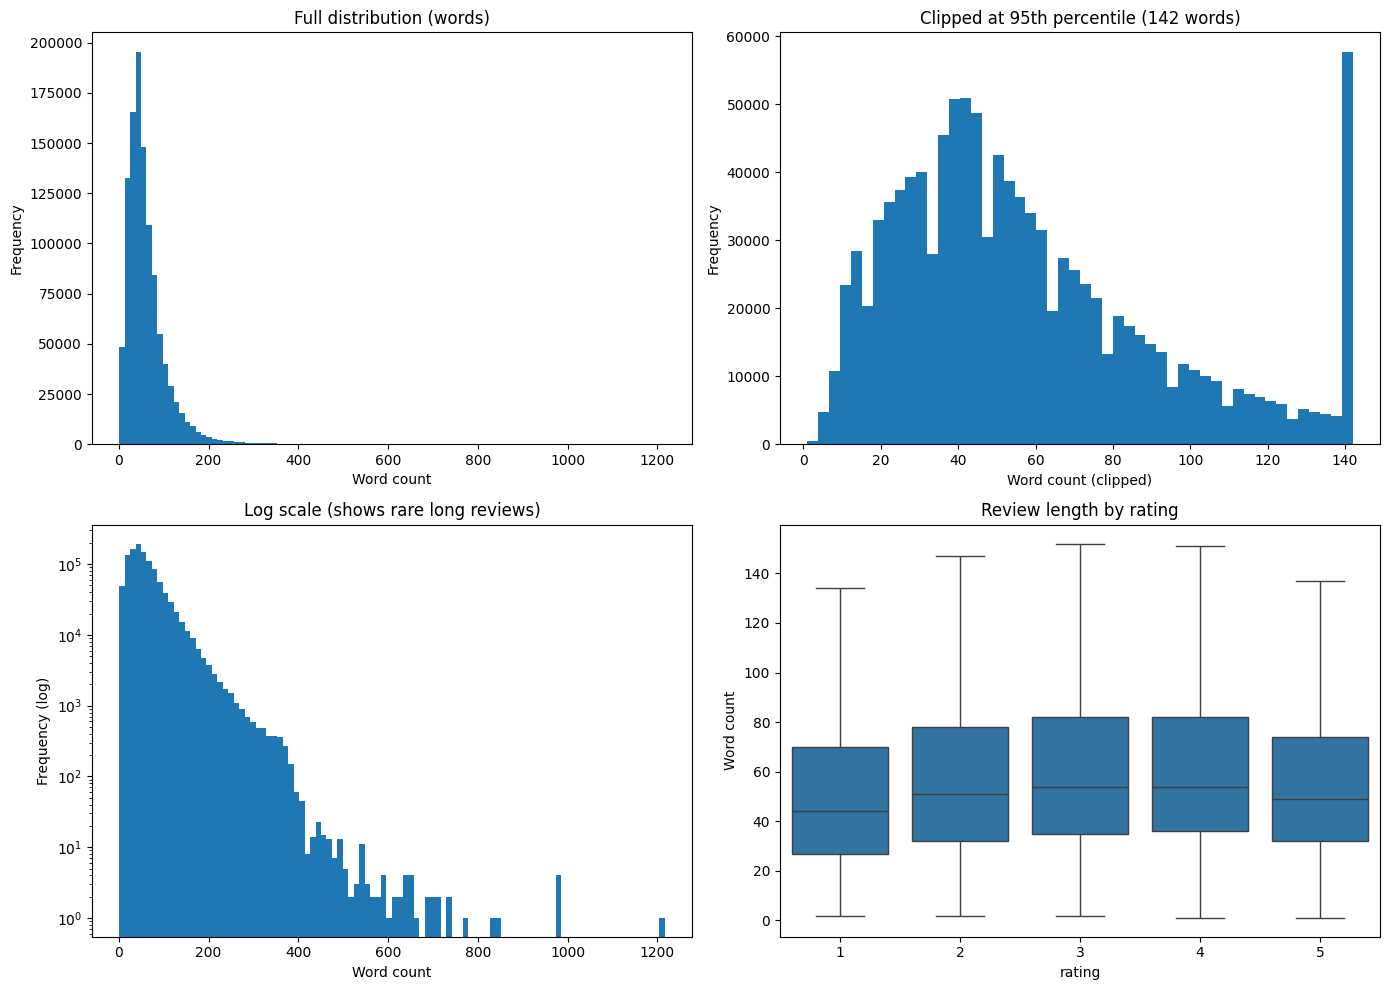

In [ ]:
# Review length distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Full distribution - often long-tail
axes[0, 0].hist(review['review_length_words'], bins=100)
axes[0, 0].set_title('Full distribution (words)')
axes[0, 0].set_xlabel('Word count')
axes[0, 0].set_ylabel('Frequency')

# (2) Clipped at 95th percentile to see bulk clearly
p95 = review['review_length_words'].quantile(0.95)
axes[0, 1].hist(review['review_length_words'].clip(upper=p95), bins=50)
axes[0, 1].set_title(f'Clipped at 95th percentile ({p95:.0f} words)')
axes[0, 1].set_xlabel('Word count (clipped)')
axes[0, 1].set_ylabel('Frequency')

# (3) Log scale to see the tail
axes[1, 0].hist(review['review_length_words'], bins=100)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Log scale (shows rare long reviews)')
axes[1, 0].set_xlabel('Word count')
axes[1, 0].set_ylabel('Frequency (log)')

# (4) Length by rating (is there a pattern?)
sns.boxplot(data=review, x='rating', y='review_length_words',
            ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title('Review length by rating')
axes[1, 1].set_ylabel('Word count')

plt.tight_layout()
plt.show()

Top 10 with most reviews

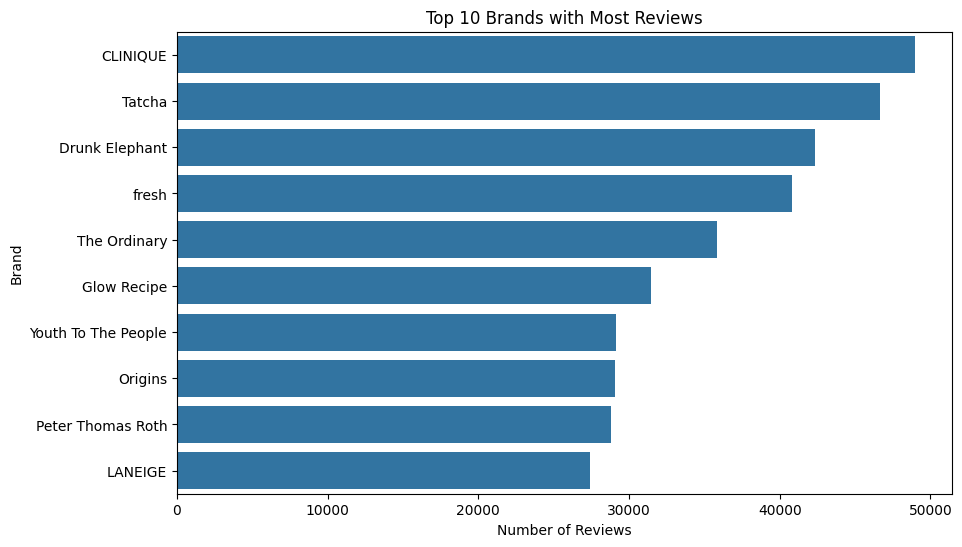

In [ ]:
# Top 10 brands with most reviews
top_brands = review['brand_name'].value_counts().head(10).reset_index()
#convert back to string type instead of category to show clearly
top_brands['brand_name'] = top_brands['brand_name'].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(data=top_brands, x='count', y='brand_name')

plt.title("Top 10 Brands with Most Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Brand")

plt.show()

In [ ]:
print(top_brands)

            brand_name  count
0             CLINIQUE  48977
1               Tatcha  46687
2       Drunk Elephant  42309
3                fresh  40828
4         The Ordinary  35809
5          Glow Recipe  31473
6  Youth To The People  29119
7              Origins  29042
8    Peter Thomas Roth  28818
9              LANEIGE  27425


Top 10 with most reviews with rating distribution

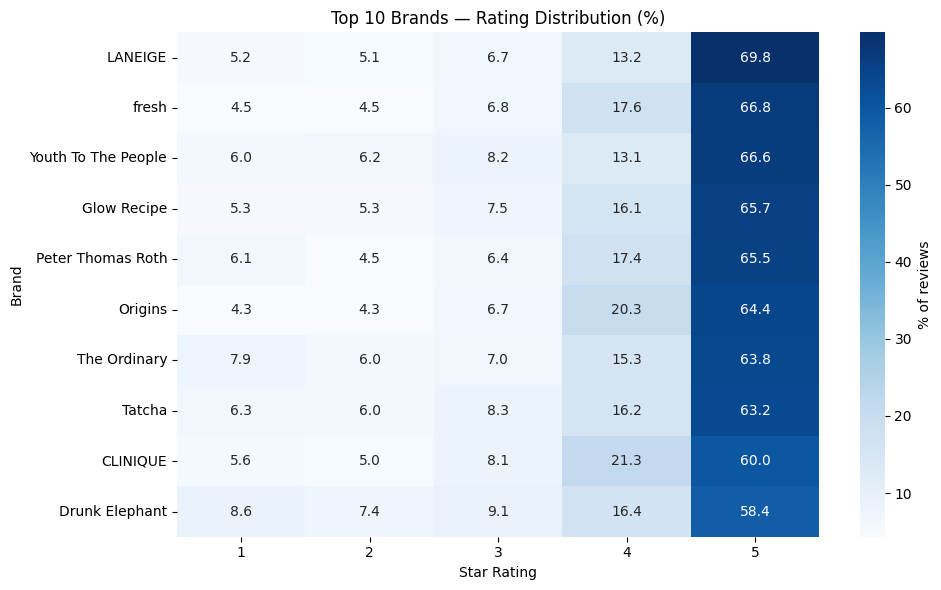

In [ ]:
top10 = top_brands['brand_name'].tolist()

# Filter to top 10 brands only
top_reviews = review[review['brand_name'].astype(str).isin(top10)].copy()

# Crosstab normalized by row (% per brand)
pivot = pd.crosstab(
    top_reviews['brand_name'].astype(str),
    top_reviews['rating'],
    normalize='index'   # each row sums to 1 (100%)
) * 100

# Sort by % 5-star rating descending
pivot = pivot.sort_values(by=5, ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': '% of reviews'})

plt.title("Top 10 Brands — Rating Distribution (%)")
plt.xlabel("Star Rating")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

Get top word frequency from reviews with 5 star and 1 star to add-in dictionary
POS tagging -> Take sample of 5-star and 1-star reviews -> Extract top ADJ

Running POS tagging on 5-star reviews sample...
Running POS tagging on 1-star reviews sample...


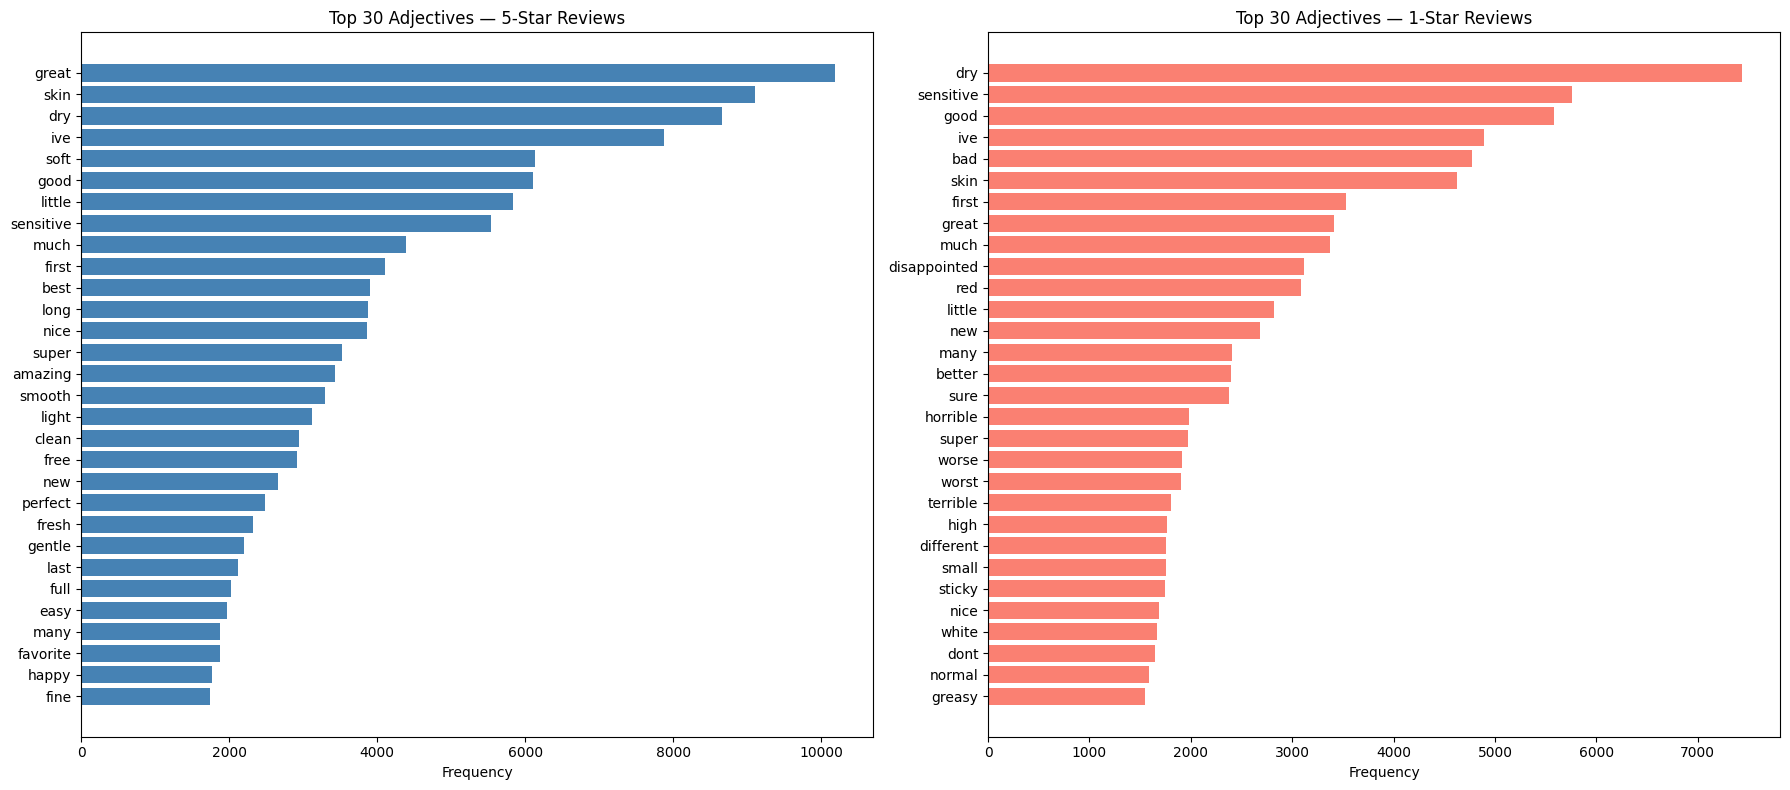

In [ ]:
import nltk
from nltk import pos_tag
from collections import Counter
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def get_top_adjectives(df, rating, sample_n=50_000, top_n=30):
    """
    Extract top adjectives from reviews of a given rating.
    Uses a sample to avoid memory/time issues on 1M+ rows.
    """
    # Filter by rating + sample
    texts = (
        df[df['rating'] == rating]['clean_text_absa']
        .dropna()
        .sample(n=min(sample_n, len(df[df['rating'] == rating])),
                random_state=42)
    )

    all_adj = []
    for text in texts:
        tokens = text.split()
        tagged = pos_tag(tokens)
        # JJ = adjective, JJR = comparative, JJS = superlative
        adjs = [word for word, tag in tagged
                if tag in ('JJ', 'JJR', 'JJS')
                and word not in stop_words
                and len(word) > 2]
        all_adj.extend(adjs)

    return Counter(all_adj).most_common(top_n)

print("Running POS tagging on 5-star reviews sample...")
top_adj_5 = get_top_adjectives(review, rating=5)

print("Running POS tagging on 1-star reviews sample...")
top_adj_1 = get_top_adjectives(review, rating=1)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

words_5, counts_5 = zip(*top_adj_5)
axes[0].barh(words_5, counts_5, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 30 Adjectives — 5-Star Reviews')
axes[0].set_xlabel('Frequency')

words_1, counts_1 = zip(*top_adj_1)
axes[1].barh(words_1, counts_1, color='salmon')
axes[1].invert_yaxis()
axes[1].set_title('Top 30 Adjectives — 1-Star Reviews')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

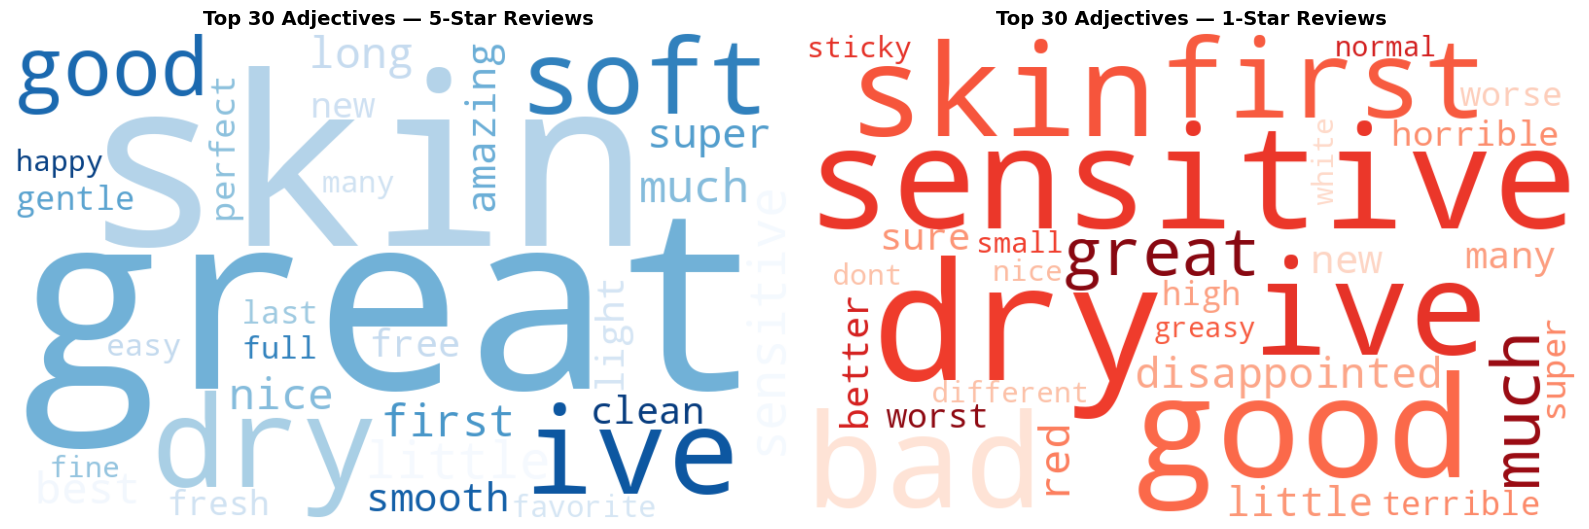

In [ ]:
!pip install wordcloud --quiet

from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Convert top 30 adjectives to dict {word: frequency}
dict_5star = dict(top_adj_5)
dict_1star  = dict(top_adj_1)

# 5-star word cloud
wc_5 = WordCloud(
    width=800, height=500,
    background_color='white',
    colormap='Blues',
    max_words=30,
).generate_from_frequencies(dict_5star)

# 1-star word cloud
wc_1 = WordCloud(
    width=800, height=500,
    background_color='white',
    colormap='Reds',
    max_words=30,
).generate_from_frequencies(dict_1star)

axes[0].imshow(wc_5, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Top 30 Adjectives — 5-Star Reviews', fontsize=14, fontweight='bold')

axes[1].imshow(wc_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Top 30 Adjectives — 1-Star Reviews', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

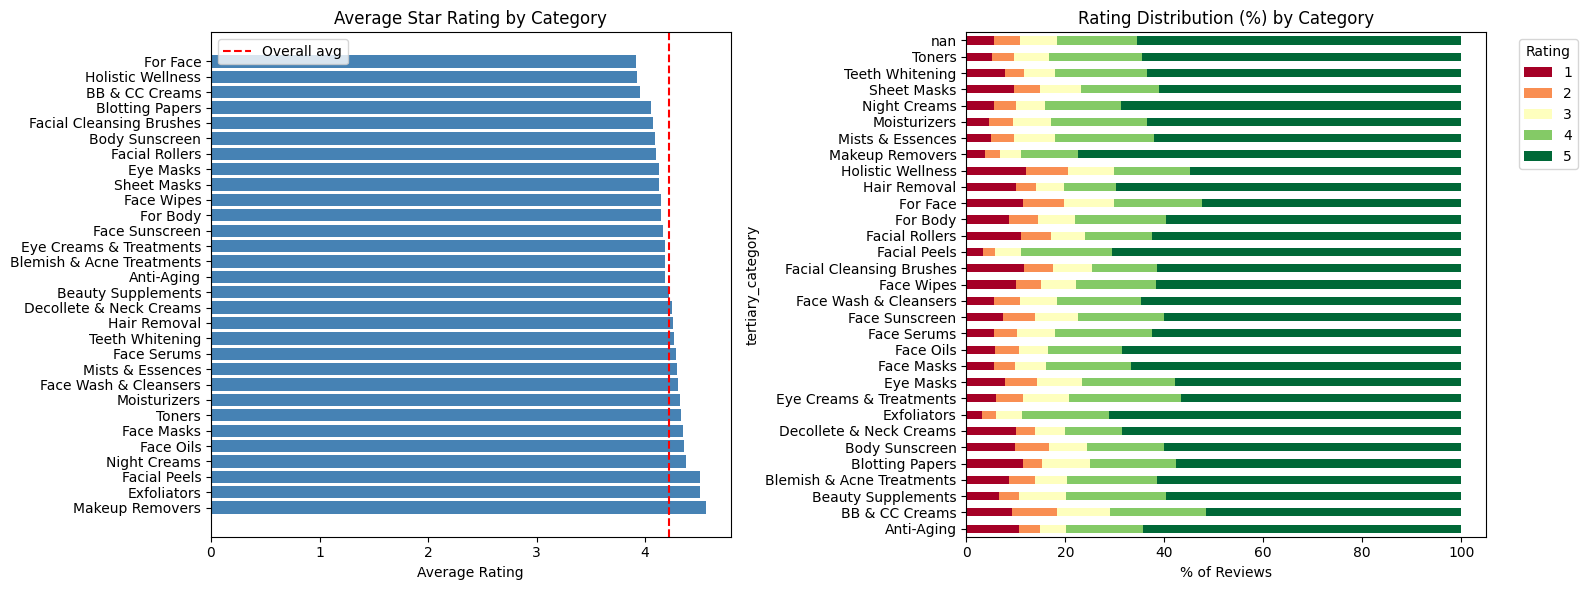

                            count  mean  pct_5star  pct_1star
tertiary_category                                            
Makeup Removers             11210  4.56      77.50       3.68
Exfoliators                 26828  4.51      71.22       3.16
Facial Peels                27632  4.50      70.53       3.39
Night Creams                 8887  4.37      68.72       5.55
Face Oils                   41824  4.36      68.46       5.70
Face Masks                  66741  4.35      66.75       5.50
Toners                      35799  4.33      64.49       5.23
Moisturizers               205942  4.32      63.53       4.65
Face Wash & Cleansers      121571  4.30      64.65       5.60
Mists & Essences            31616  4.30      62.06       4.94
Face Serums                174384  4.29      62.49       5.66
Hair Removal                  581  4.26      69.71       9.98
Teeth Whitening               971  4.26      63.54       7.72
Decollete & Neck Creams       960  4.25      68.65      10.00
Beauty S

In [ ]:
# Rating distribution by tertiary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average rating per category (bar chart)
avg_rating = (review.groupby('tertiary_category')['rating']
              .mean()
              .sort_values(ascending=False))

axes[0].barh(avg_rating.index.astype(str), avg_rating.values, color='steelblue')
axes[0].set_title('Average Star Rating by Category')
axes[0].set_xlabel('Average Rating')
axes[0].axvline(x=avg_rating.mean(), color='red', linestyle='--', label='Overall avg')
axes[0].legend()

# Plot 2: Rating distribution per category (% stacked bar)
pivot = pd.crosstab(
    review['tertiary_category'].astype(str),
    review['rating'],
    normalize='index'
) * 100

pivot.plot(
    kind='barh',
    stacked=True,
    colormap='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Rating Distribution (%) by Category')
axes[1].set_xlabel('% of Reviews')
axes[1].legend(title='Rating', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Print summary table
print(review.groupby('tertiary_category')['rating'].agg(
    count='count',
    mean='mean',
    pct_5star=lambda x: (x == 5).mean() * 100,
    pct_1star=lambda x: (x == 1).mean() * 100
).round(2).sort_values('mean', ascending=False))

In [ ]:

print(review['tertiary_category'].nunique())
print(review['tertiary_category'].value_counts().head(20))

30
tertiary_category
Moisturizers                 205942
Face Serums                  174384
Face Wash & Cleansers        121571
Eye Creams & Treatments       70371
Face Masks                    66741
Face Oils                     41824
Face Sunscreen                39054
Toners                        35799
Mists & Essences              31616
Facial Peels                  27632
Exfoliators                   26828
Blemish & Acne Treatments     19674
Makeup Removers               11210
Night Creams                   8887
BB & CC Creams                 7873
Beauty Supplements             7718
For Face                       5746
For Body                       5127
Face Wipes                     4668
Eye Masks                      4548
Name: count, dtype: int64


## **Dictionaries**

2 dictionaries  
- Dictionary of adjectives in support for VADER. Find specific beauty related keywords/adjectives that has positive/negative meanings.
- Dictionary of nouns to match keywords for aspect based analysis. Do for each category (Eg: {Skincare:{'Scent': 'fragrance'}, {Hydration: moisture}, etc} Aim to find as much synonym for each keyword as possible but must stay relevant. For each category, at least 2 aspects.  
*Refer to Product.csv for category list*

In [ ]:
#Dictionary with scores to support VADER
beauty_lexicon = {
    # === POSITIVE ===
    # Holy grail / cult favorite
    'holy grail':        3.5,
    'game changer':      3.2,
    'game-changer':      3.2,
    'repurchase':        2.5,
    'repurchased':       2.5,
    're-purchase':       2.5,
    'ride or die':       3.0,
    'staple':            2.0,
    'go-to':             2.0,
    'must have':         2.8,
    'must-have':         2.8,
    'cant live without': 3.2,

    # Skin results — positive
    'glowy':             2.5,
    'dewy':              2.0,
    'plump':             2.0,
    'plumped':           2.0,
    'plumping':           2.0,
    'bouncy':            2.0,    # bouncy skin = hydrated
    'glass skin':        3.0,
    'snatched':          2.5,    # slang for looking good
    'glowing':           2.5,
    'lit from within':   3.0,
    'second skin':       2.5,    # feels like second skin
    'melts in':          2.0,    # melts into skin
    'blurs':             2.0,    # blurs pores/imperfections
    'blurring':          2.0,
    'poreless':          2.5,
    'skin looks poreless': 2.5,

    # Product performance — positive
    'pigmented':         2.5,
    'full coverage':     2.0,
    'buildable':         1.5,
    'long lasting':      2.5,
    'long-lasting':      2.5,
    'wear all day':      2.5,
    'wears well':        2.0,
    'transfer proof':    2.0,
    'transfer-proof':    2.0,
    'budge proof':       2.0,
    'budge-proof':       2.0,
    'no creasing':       2.0,
    'no fading':         2.0,
    'absorbs quickly':   2.0,
    'absorbs fast':      2.0,
    'sinks in':          1.8,
    'non greasy':        1.5,
    'non-greasy':        1.5,
    'lightweight':       1.5,
    'breathable':        1.5,

    # === NEGATIVE ===
    # Skin reaction
    'broke me out':      -3.5,
    'breaking me out':   -3.5,
    'breaks me out':     -3.5,
    'caused me break out': -3.5,
    'clogged pores':     -2.5,
    'clogs pores':       -2.5,
    'pilling':           -2.0,   # product pills on skin
    'pills':             -1.5,
    'cakey':             -2.5,
    'cakes up':          -2.0,
    'flashback':         -2.0,   # white cast in photos
    'white cast':        -2.5,
    'ashy':              -2.0,   # product looks ashy on skin
    'oxidizes':          -2.0,   # foundation oxidizes/turns orange
    'oxidized':          -2.0,
    'turns orange':      -2.5,
    'patchy':            -2.5,
    'patchiness':        -2.5,
    'settles into lines': -2.5,
    'settles in lines':  -2.5,
    'creases':           -2.0,
    'emphasizes pores':  -2.0,
    'accentuates pores': -2.0,

    # Product performance — negative
    'not pigmented':     -2.5,
    'not pigmented enough': -2.5,
    'sheer':             -1.0,   # context-dependent but often negative for foundation
    'fades quickly':     -2.0,
    'fades fast':        -2.0,
    'wears off':         -2.0,
    'transfers':         -1.5,
    'melts off':         -2.0,
    'slides off':        -2.0,
    'not worth':         -2.8,
    'not worth it':      -2.8,
    'waste of money':    -3.3,
    'overpriced':        -2.5,
    'return it':         -3.0,
    'returned it':       -3.0,
    'threw it away':     -3.0,

    # Texture/feel — negative
    'sticky':            -1.5,
    'tacky':             -1.5,
    'greasy':            -2.0,
    'heavy':             -1.0,   # context-dependent
    'thick':             -0.5,   # context-dependent
    'goopy':             -1.5,
    'chunky':            -1.5,
    'flaky':             -1.5,

    # General dissatisfaction
    'overhyped':         -2.5,
    'over hyped':        -2.5,
    'not worth the hype': -3.0,
    'doesnt work':       -2.5,
    "doesn't work":      -2.5,
    'did nothing':       -2.5,
    'does nothing':      -2.5,
    'no difference':     -2.0,
    'no results':        -2.0,
    'snake oil':         -3.0,
    'not a big fan of':  -1.0,
}



Aspect dict - Skincare-specific for each sub-cate and universal for all cate

In [ ]:
# Dictionary 2: aspect-based keyword dictionary
#this dict will be apply on ABSA normalized phrase so only need words in root forms.

aspect_dict = {
    'skincare-specific':{
        'hydration': {
            'moisture': ['moisture', 'hydration',  'hydrate'],
            'dryness': ['dry', 'dryness', 'dehydrated', 'flaky', 'chapped']
                         },
        'texture': {
            'feel': ['texture', 'smooth', 'soft', 'silky', 'creamy', 'velvety'],
            'consistency': ['thick', 'thin', 'lightweight', 'heavy', 'sticky', 'tacky', 'greasy']
            },
        'scent': {
            'fragrance': ['scent', 'smell', 'fragrance', 'odor', 'perfume','fragrance-free', 'unscented', 'no smell','chemical', 'fresh']
            },
        'performance': {
            'effectiveness': ['effective', 'work', 'result', 'improvement', 'benefit', 'difference'],
            'irritation': ['irritating', 'harsh', 'burning', 'allergic', 'sensitive', 'sting'],
            'comfort': ['gentle', 'soothing', 'calming']
            },

        'finish': {
            'look': ['glow', 'glowy', 'radiant', 'bright', 'dewy', 'matte'],
            'appearance': ['smooth', 'even', 'brightening', 'dull', 'patchy', 'cakey', 'pilling', 'white cast']
            },
        'skin_concern': {
            'acne':        ['acne', 'pimple', 'breakout', 'blemish','clogged pores', 'blackhead', 'congestion','broke me out', 'purge', 'break out', ],
            'aging':       ['fine lines', 'wrinkles', 'aging', 'firming','lifting', 'plumping', 'collagen', 'elasticity'],
            'brightening': ['dark spot', 'hyperpigmentation', 'discoloration','even skin tone', 'vitamin c','dull', 'glow'],
            'sensitivity': ['sensitive skin', 'reactive', 'rosacea','eczema', 'redness', 'calm', 'barrier'],
            },
        'absorption': ['absorb', 'sink in' , 'residue', 'dry down', 'melts in','pilling' ]
    },
    'universal':{
        'packaging': {
            'container': ['bottle','tube','pump','dispenser'],
            'quality': ['leak','broke','crack','shatter','spill','sturdy','durable','cheap']
            },
        'price':{
            'positive': ['affordable', 'worth', 'value', 'reasonable', 'budget', 'bargain', 'cost effective', 'good deal'],
            'negative': ['expensive', 'overpriced', 'pricey', 'steep', 'not worth', 'waste of money', 'too much']
            },
        'service': {
            'shipping': ['ship', 'deliver', 'arrive', 'transit', 'tracking', 'delay', 'fast delivery', 'damaged', 'package'],
            'customer_service': ['refund', 'exchange', 'support', 'response', 'helpful', 'rude', 'resolve'],
    }}
}

print("Categories:", list(aspect_dict.keys()))

Categories: ['skincare-specific', 'universal']


#**VADER**

In [ ]:
review.head()

,author_id,rating,is_recommended,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,review_text_vader,clean_text_absa,sentences,tertiary_category,review_length_words
0,1741593524,5,1.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,I use this with the Nudestix “Citrus Clean Bal...,i use this with the nudestix citrus clean balm...,[I use this with the Nudestix “Citrus Clean Ba...,NaN,79
1,31423088263,1,0.0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I bought this lip mask after reading the revie...,i bought this lip mask after reading the revie...,[I bought this lip mask after reading the revi...,NaN,28
2,5061282401,5,1.0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,My review title says it all! I get so excited ...,my review title says it all i get so excited t...,"[My review title says it all!, I get so excite...",NaN,53
3,6083038851,5,1.0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,I’ve always loved this formula for a long time...,ive always loved this formula for a long time ...,[I’ve always loved this formula for a long tim...,NaN,45
4,47056667835,5,1.0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"If you have dry cracked lips, this is a must h...",if you have dry cracked lips this is a must ha...,"[If you have dry cracked lips, this is a must ...",NaN,46


In [ ]:
!pip install vaderSentiment --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Add to VADER lexicon
analyzer.lexicon.update(beauty_lexicon)

def score_sentences(sentences):
    """Average compound score across sentences in a review."""
    if not sentences or len(sentences) == 0:
        return 0.0
    scores = [analyzer.polarity_scores(s)['compound'] for s in sentences]
    return sum(scores) / len(scores)

def score_text(text):
    """Score a single text (for title — usually 1 sentence)."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    return analyzer.polarity_scores(text.strip())['compound']

# Body: score using pre-split sentences
review['vader_compound'] = review['sentences'].apply(score_sentences)

# Title: score directly on raw text
review['title_compound'] = review['review_title'].apply(score_text)

# Verify
print(review[['review_text_vader', 'vader_compound',
              'review_title', 'title_compound']].head())
print(f"\nMemory: {review.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

                                   review_text_vader  vader_compound  \
0  I use this with the Nudestix “Citrus Clean Bal...        0.441067   
1  I bought this lip mask after reading the revie...        0.064000   
2  My review title says it all! I get so excited ...       -0.012560   
3  I’ve always loved this formula for a long time...        0.388667   
4  If you have dry cracked lips, this is a must h...        0.056575   

                       review_title  title_compound  
0  Taught me how to double cleanse!          0.0000  
1                      Disappointed         -0.4767  
2              New Favorite Routine          0.4588  
3   Can't go wrong with any of them          0.3724  
4                   A must have !!!          0.0000  

Memory: 2532 MB


In [ ]:
review[['review_text_vader', 'vader_compound',
              'review_title', 'title_compound']].head()

,review_text_vader,vader_compound,review_title,title_compound
0,I use this with the Nudestix “Citrus Clean Bal...,0.441067,Taught me how to double cleanse!,0.0000
1,I bought this lip mask after reading the revie...,0.064000,Disappointed,-0.4767
2,My review title says it all! I get so excited ...,-0.012560,New Favorite Routine,0.4588
3,I’ve always loved this formula for a long time...,0.388667,Can't go wrong with any of them,0.3724
4,"If you have dry cracked lips, this is a must h...",0.056575,A must have !!!,0.0000


Vader score translate to label, comparing to ground truth

In [ ]:
def compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'


def rating_to_label(rating):
    if rating >= 4:       # 4 and 5 = positive
        return 'positive'
    elif rating == 3:     # 3 = neutral
        return 'neutral'
    else:                 # 1 và 2 = negative
        return 'negative'


# Create labels
review['vader_label']  = review['vader_compound'].apply(compound_to_label)
review['title_label']  = review['title_compound'].apply(compound_to_label)
review['rating_label'] = review['rating'].apply(rating_to_label)

# Quick check distribution
print(review['vader_label'].value_counts(normalize=True).mul(100).round(1))
print(review['title_label'].value_counts(normalize=True).mul(100).round(1))
print(review['rating_label'].value_counts(normalize=True).mul(100).round(1))

vader_label
positive    86.9
neutral      6.8
negative     6.3
Name: proportion, dtype: float64
title_label
neutral     50.1
positive    43.3
negative     6.6
Name: proportion, dtype: float64
rating_label
positive    82.1
negative    10.4
neutral      7.5
Name: proportion, dtype: float64


In [ ]:
print(review.groupby('rating')['vader_compound'].agg(
    mean='mean',
    median='median',
    count='count'
).round(3))

         mean  median   count
rating                       
1      -0.017   0.000   61105
2       0.094   0.098   52956
3       0.203   0.202   81752
4       0.339   0.335  199211
5       0.374   0.369  697943


In [ ]:
sample_3star = review[review['rating'] == 3][
    ['review_text', 'rating']
].sample(30, random_state=42)


Manual checking sentiment of random 3&4 star rating

In [ ]:
for i, (idx, row) in enumerate(sample_3star.iterrows(), 1):
    print(f"--- Review {i} ---")
    print(row['review_text'])
    print()

--- Review 1 ---
I used this product paired with tatcha cleanser for a few weeks before bed and although I didn’t get any new breakouts, it is just not hydrating enough. I would wake up in the morning and feel the need to apply a heavier moisturizer (I use the one from first aid beauty). The scent was not overwhelming, but I found the texture quite odd when I went to apply it on my face (probably just because I wasn’t used to it). I also compared it many other moisturizers I’ve used in the past, and I felt as though I needed to apply so much of this product to get my entire face, and for this price I don’t think it’s worth it !!

--- Review 2 ---
I received this #freeproduct from #trywithtopbox in exchange for my honest opinion. I liked that it’s fragrance free. But I didn’t like that it felt greasy on my face.

--- Review 3 ---
I had very high hopes for this eye cream as I have tried a few Sunday Riley products in the past with good results. I found this eye cream very oily and I coul

In [ ]:
sample_4star = review[review['rating'] == 4][
    ['review_text', 'rating']
].sample(30, random_state=42)

for i, (idx, row) in enumerate(sample_4star.iterrows(), 1):
    print(f"--- Review {i} ---")
    print(row['review_text'])
    print()

--- Review 1 ---
This cream is amazing especially if you have dry skin. My skin is sometimes all over the place either being oily or very dry and this product help nourish my dry spots. It absorbs quickly and leaves my face feeling hydrated. This product also works really well under makeup.

--- Review 2 ---
I have been enjoying this product. I received it in the mail to try and was a little skeptical at first. I am someone who enjoys lotion sunscreens but this one was shockingly good! It’s perfect to keep in your purse and glides on the skin nicely. It’s very velvety and doesn’t feel too greasy. Price point is a little high but if you feel like traveling, this ones for you!

--- Review 3 ---
Beautiful balm, great for slugging! Especially in the winter, it was so useful to layer over my daily moisturizer. Rather expensive but worth the hype.

--- Review 4 ---
This product is really great for hydrating your lips. If this is a little bit on the pricier side than I would recommend somethi

Confusion matrix - Evaluation of Vader vs ground truth

=== VADER Body vs Rating ===
              precision    recall  f1-score   support

    positive       0.88      0.93      0.90    897154
     neutral       0.13      0.12      0.13     81752
    negative       0.56      0.33      0.42    114061

    accuracy                           0.81   1092967
   macro avg       0.52      0.46      0.48   1092967
weighted avg       0.79      0.81      0.79   1092967



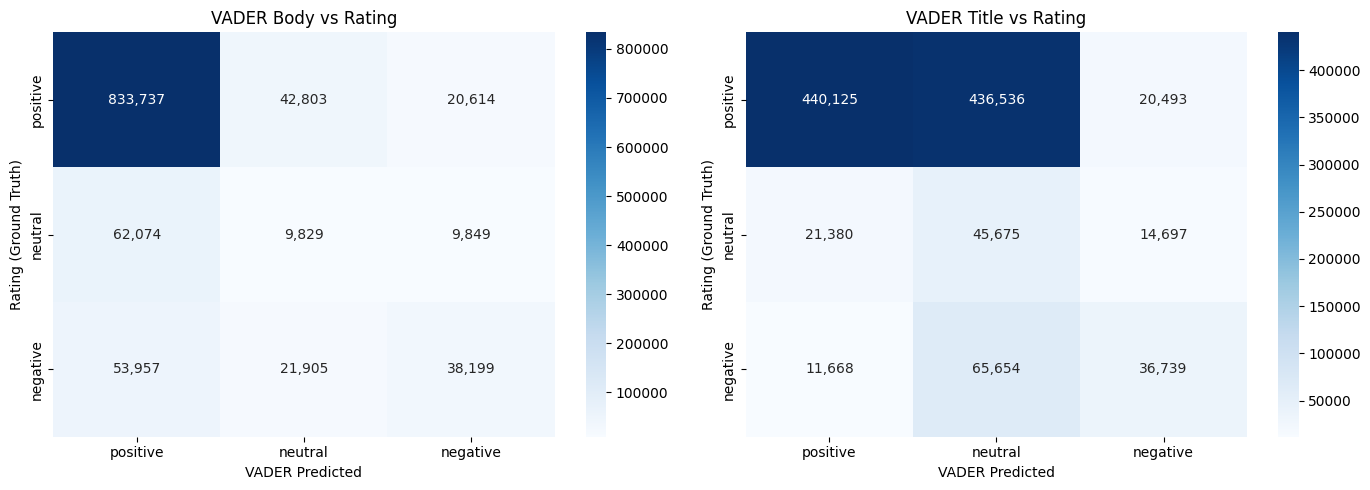

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. VADER body vs rating
print("=== VADER Body vs Rating ===")
print(classification_report(
    review['rating_label'],
    review['vader_label'],
    labels=['positive', 'neutral', 'negative']
))

# 2. Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred_col, title in zip(
    axes,
    ['vader_label', 'title_label'],
    ['VADER Body vs Rating', 'VADER Title vs Rating']
):
    cm = confusion_matrix(
        review['rating_label'],
        review[pred_col],
        labels=['positive', 'neutral', 'negative']
    )
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['positive', 'neutral', 'negative'],
                yticklabels=['positive', 'neutral', 'negative'])
    ax.set_title(title)
    ax.set_xlabel('VADER Predicted')
    ax.set_ylabel('Rating (Ground Truth)')

plt.tight_layout()
plt.show()

In [ ]:
# Reviews misclassified
misclassified_neg = review[
    (review['rating_label'] == 'negative') &
    (review['vader_label'] != 'negative')
]

print(f"Total misclassified: {len(misclassified_neg):,}")
print(f"\n10 samples:")
for i, row in misclassified_neg.sample(10, random_state=42).iterrows():
    print(f"\n  Rating: {row['rating']} | VADER: {row['vader_label']} (compound: {row['vader_compound']:.3f})")
    print(f"  Text: {row['review_text_vader']}")

Total misclassified: 75,862

10 samples:

  Rating: 2 | VADER: positive (compound: 0.068)
  Text: Although this cleanser was great for removing my makeup, I found it quite irritating to my skin.  I usually do not have sensitive skin, but this had my skin red, blotchy and bumpy and there was a slight stinging sensation all over my face.  I have decided to discontinue use as it is not right for my skin.

  Rating: 1 | VADER: positive (compound: 0.120)
  Text: I gave it 1 star for the package, the press to dispense flat top is really convenience. The cream itself felt nice at application. I have dry skin, and this cream made my face feel cracking, and itchy, and it get worse everytime I used it. I didn’t save the receipt and couldn’t return it.

  Rating: 2 | VADER: positive (compound: 0.244)
  Text: I’ve been using this cleanser for two months now and I’m honestly not in love with it.  I was actually really put off with it the first two weeks because it didn’t feel like it cleaned deep e

In [ ]:
from sklearn.metrics import classification_report

print("=== VADER Body vs Rating ===")
print(classification_report(
    review['rating_label'],
    review['vader_label'],
    labels=['positive', 'neutral', 'negative'],
    digits=3
))

print("=== VADER Title vs Rating ===")
print(classification_report(
    review['rating_label'],
    review['title_label'],
    labels=['positive', 'neutral', 'negative'],
    digits=3
))

=== VADER Body vs Rating ===
              precision    recall  f1-score   support

    positive      0.878     0.929     0.903    897154
     neutral      0.132     0.120     0.126     81752
    negative      0.556     0.335     0.418    114061

    accuracy                          0.807   1092967
   macro avg      0.522     0.461     0.482   1092967
weighted avg      0.788     0.807     0.794   1092967

=== VADER Title vs Rating ===
              precision    recall  f1-score   support

    positive      0.930     0.491     0.642    897154
     neutral      0.083     0.559     0.145     81752
    negative      0.511     0.322     0.395    114061

    accuracy                          0.478   1092967
   macro avg      0.508     0.457     0.394   1092967
weighted avg      0.823     0.478     0.579   1092967



#**ABSA**

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def normalize_sentence(sentence):
    """Normalize a sentence for aspect keyword matching."""
    text = re.sub(r'[^\w\s]', '', sentence.lower())
    tokens = [lemmatizer.lemmatize(w) for w in text.split()]
    return ' '.join(tokens)

def match_aspects(sent_norm):
    matched = []
    for category, aspects in aspect_dict.items():          # level 1: skincare-specific / universal
        if isinstance(aspects, dict):
            for aspect, sub in aspects.items():             # level 2: hydration, texture...
                if isinstance(sub, dict):
                    for sub_aspect, keywords in sub.items(): # level 3: feel, consistency...
                        if isinstance(keywords, list) and any(kw in sent_norm for kw in keywords):
                            matched.append(f"{category}_{aspect}_{sub_aspect}")
                elif isinstance(sub, list):
                    if any(kw in sent_norm for kw in sub):
                        matched.append(f"{category}_{aspect}")
    return matched

def absa_one_review(sentences):
    """
    For each sentence in a review:
    - Normalize for aspect matching
    - Match aspects on normalized text
    - Score sentiment on raw sentence
    Returns list of dicts: {aspect, score, sentence}
    """
    results = []
    for sent_raw in sentences:
        sent_norm = normalize_sentence(sent_raw)
        matched = match_aspects(sent_norm)

        if matched:
            score = analyzer.polarity_scores(sent_raw)['compound']
            for aspect in matched:
                results.append({
                    'aspect': aspect,
                    'score':  score,
                })
    return results

# Apply to df
review['absa_results'] = review['sentences'].apply(absa_one_review)

# Quick check
print(review['absa_results'].iloc[0])
print(f"\nReviews with at least 1 aspect matched: "
      f"{review['absa_results'].apply(len).gt(0).sum():,}")

[]

Reviews with at least 1 aspect matched: 1,015,050


In [ ]:
# Show reviews with matches
matched_reviews = review[review['absa_results'].apply(len) > 0]
print(matched_reviews['absa_results'].iloc[0])
print(matched_reviews['review_text'].iloc[0])

[{'aspect': 'skincare-specific_performance_effectiveness', 'score': 0.128}]
I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.


to check the unmatched aspect comments

In [ ]:
# Check unmatched reviews
unmatched = review[review['absa_results'].apply(len) == 0]
print(f"Unmatched: {len(unmatched):,}")
print(f"Avg length (words): {unmatched['review_length_words'].mean():.0f}")
print(f"\nSample unmatched reviews:")
for text in unmatched['review_text_vader'].sample(10, random_state=42):
    print(f"  → {text[:200]}")

Unmatched: 77,917
Avg length (words): 28

Sample unmatched reviews:
  → Not my favourite...I didn’t feel like it looked natural on my skin. It made my skin look very oily and slightly metallic.
  → This night cream is amazing and my skin has been loving it. It is hydrating and feels so good on my face. My forehead lines have become less noticable after a short time. Retinol used to scare me but 
  → Great feel to this. I’ve been searching for a high quality serum and this one is great.
  → I’m blown away honestly. This is like having a facial. And it’s only 10 minutes mask! Will keep using it at least once a week.
  → Great lip balm. I always keep one in my bag.
  → I love this product!! It literally is a cloud on your face and makes you feel amazing! I highly suggest grabbing this product!!
  → I love these eye masks, my skin feels so good afterwards and I feel like a queen with some gold and rose gold under my eyes. What a treat! I’ve just repurchased one rose gold and one gold set. 

In [ ]:
# Pick the "GREASY" review
test_text = "I have the average oily t-zone but this product made my face GREASY"
test_sentences = sent_tokenize(test_text)

for sent in test_sentences:
    norm = normalize_sentence(sent)
    matched = match_aspects(norm)
    print(f"  SENT: {sent}")
    print(f"  NORM: {norm}")
    print(f"  MATCHED: {matched}")
    print()

# Also check: is 'greasy' actually findable in normalized text?
print("'greasy' in norm?", 'greasy' in normalize_sentence(test_text))

  SENT: I have the average oily t-zone but this product made my face GREASY
  NORM: i have the average oily tzone but this product made my face greasy
  MATCHED: ['skincare-specific_texture_consistency']

'greasy' in norm? True


AVG Score by aspect

In [ ]:
absa_exploded = review.explode('absa_results').dropna(subset=['absa_results'])

# Extract aspect and score from dict
absa_exploded['aspect'] = absa_exploded['absa_results'].apply(lambda x: x['aspect'])
absa_exploded['score']  = absa_exploded['absa_results'].apply(lambda x: x['score'])

# Average VADER score per aspect only
absa_aspect_summary = (absa_exploded.groupby('aspect')['score'].agg(avg_score='mean', count='count')
    .reset_index()
    .sort_values('avg_score', ascending=False)
    .round(3)
)

print(absa_aspect_summary)

                                         aspect  avg_score   count
5         skincare-specific_performance_comfort      0.613   69495
19           universal_service_customer_service      0.606   25763
2                 skincare-specific_finish_look      0.529  211508
11   skincare-specific_skin_concern_brightening      0.443  168449
10         skincare-specific_skin_concern_aging      0.421   78522
8             skincare-specific_scent_fragrance      0.408  397245
18                     universal_price_positive      0.400   77934
14               skincare-specific_texture_feel      0.349  372485
4          skincare-specific_hydration_moisture      0.347  166433
6   skincare-specific_performance_effectiveness      0.333  415423
0                  skincare-specific_absorption      0.298  100746
20                   universal_service_shipping      0.279   16775
1           skincare-specific_finish_appearance      0.277  335488
12   skincare-specific_skin_concern_sensitivity      0.259  14

AVG Score by sub-cate

In [ ]:
review.head()

,author_id,rating,is_recommended,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,...,clean_text_absa,sentences,tertiary_category,review_length_words,vader_compound,title_compound,vader_label,title_label,rating_label,absa_results
0,1741593524,5,1.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,...,i use this with the nudestix citrus clean balm...,[I use this with the Nudestix “Citrus Clean Ba...,NaN,79,0.441067,0.0000,positive,neutral,positive,[]
1,31423088263,1,0.0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,...,i bought this lip mask after reading the revie...,[I bought this lip mask after reading the revi...,NaN,28,0.064000,-0.4767,positive,negative,negative,[{'aspect': 'skincare-specific_performance_eff...
2,5061282401,5,1.0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,...,my review title says it all i get so excited t...,"[My review title says it all!, I get so excite...",NaN,53,-0.012560,0.4588,neutral,positive,positive,[{'aspect': 'skincare-specific_hydration_dryne...
3,6083038851,5,1.0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,...,ive always loved this formula for a long time ...,[I’ve always loved this formula for a long tim...,NaN,45,0.388667,0.3724,positive,positive,positive,[{'aspect': 'skincare-specific_finish_appearan...
4,47056667835,5,1.0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,...,if you have dry cracked lips this is a must ha...,"[If you have dry cracked lips, this is a must ...",NaN,46,0.056575,0.0000,positive,neutral,positive,[{'aspect': 'skincare-specific_hydration_dryne...


In [ ]:
print(absa_exploded.columns.tolist())
print(absa_exploded.head(2))

['author_id', 'rating', 'is_recommended', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'review_text_vader', 'clean_text_absa', 'sentences', 'tertiary_category', 'review_length_words', 'vader_compound', 'title_compound', 'vader_label', 'title_label', 'rating_label', 'absa_results', 'aspect', 'score']
     author_id  rating  is_recommended submission_time  \
1  31423088263       1             0.0      2023-03-21   
2   5061282401       5             1.0      2023-03-21   

                                         review_text          review_title  \
1  I bought this lip mask after reading the revie...          Disappointed   
2  My review title says it all! I get so excited ...  New Favorite Routine   

  skin_tone eye_color skin_type hair_color  ... tertiary_category  \
1       NaN       NaN       NaN        NaN  ...               NaN   
2     light     brown       dry     

In [ ]:
absa_category_summary = (
    absa_exploded
    .groupby('tertiary_category')['score']
    .agg(avg_score='mean', count='count')
    .reset_index()
    .sort_values('avg_score', ascending=False)
    .round(3)
)

print(absa_category_summary)

            tertiary_category  avg_score   count
7                 Exfoliators      0.348  103371
16   Facial Cleansing Brushes      0.347    3186
24           Mists & Essences      0.342  123605
15                 Face Wipes      0.342   10427
8     Eye Creams & Treatments      0.331  229292
14      Face Wash & Cleansers      0.327  396651
5              Body Sunscreen      0.324    4197
23            Makeup Removers      0.319   27827
25               Moisturizers      0.319  832731
6     Decollete & Neck Creams      0.318    3660
19                   For Body      0.317   13849
12                Face Serums      0.317  729808
10                 Face Masks      0.314  266572
27                Sheet Masks      0.314   11790
0                  Anti-Aging      0.310    9051
29                     Toners      0.308  133210
18             Facial Rollers      0.308    2932
9                   Eye Masks      0.305   12570
26               Night Creams      0.305   38771
17               Fac

In [ ]:
pivot_summary = (
    absa_exploded
    .groupby(['tertiary_category', 'aspect'])['score']
    .mean()
    .unstack(level='aspect')
    .round(3)
)

pivot_summary

aspect,skincare-specific_absorption,skincare-specific_finish_appearance,skincare-specific_finish_look,skincare-specific_hydration_dryness,skincare-specific_hydration_moisture,skincare-specific_performance_comfort,skincare-specific_performance_effectiveness,skincare-specific_performance_irritation,skincare-specific_scent_fragrance,skincare-specific_skin_concern_acne,...,skincare-specific_skin_concern_brightening,skincare-specific_skin_concern_sensitivity,skincare-specific_texture_consistency,skincare-specific_texture_feel,universal_packaging_container,universal_packaging_quality,universal_price_negative,universal_price_positive,universal_service_customer_service,universal_service_shipping
tertiary_category,,,,,,,,,,,,,,,,,,,,,
Anti-Aging,0.439,0.287,0.563,0.228,0.387,0.614,0.323,0.215,0.370,0.151,...,0.454,0.265,0.276,0.318,0.242,-0.082,0.132,0.355,0.503,0.190
BB & CC Creams,0.158,0.217,0.419,0.126,0.307,0.465,0.316,0.244,0.349,0.153,...,0.354,0.250,0.190,0.301,0.307,-0.147,0.116,0.360,0.576,0.270
Beauty Supplements,0.201,0.204,0.487,0.107,0.401,0.632,0.280,0.319,0.277,0.052,...,0.482,0.393,0.233,0.313,0.197,-0.101,0.124,0.364,0.606,0.311
Blemish & Acne Treatments,0.196,0.188,0.410,0.175,0.216,0.582,0.266,0.140,0.238,0.145,...,0.268,0.205,0.160,0.299,0.185,0.014,0.111,0.372,0.511,0.197
Blotting Papers,0.203,0.090,0.324,0.141,0.637,0.440,0.330,0.215,0.184,NaN,...,NaN,-0.014,0.214,-0.025,NaN,0.088,0.032,0.288,NaN,0.176
Body Sunscreen,0.331,0.201,0.525,0.283,0.483,0.787,0.390,0.174,0.390,0.057,...,0.531,0.104,0.206,0.367,0.208,-0.020,0.161,0.287,0.496,0.125
Decollete & Neck Creams,0.342,0.265,0.529,0.348,0.350,0.653,0.290,0.256,0.394,0.012,...,0.418,0.204,0.265,0.351,0.447,0.023,0.141,0.294,0.566,0.301
Exfoliators,0.252,0.308,0.525,0.200,0.349,0.622,0.373,0.257,0.465,0.172,...,0.414,0.258,0.260,0.356,0.251,0.008,0.190,0.412,0.617,0.314
Eye Creams & Treatments,0.318,0.328,0.554,0.180,0.343,0.589,0.306,0.207,0.375,0.094,...,0.487,0.225,0.271,0.361,0.259,0.146,0.157,0.373,0.623,0.332


Top 5 and bottom 5 brands with highest and lowest sentiment score

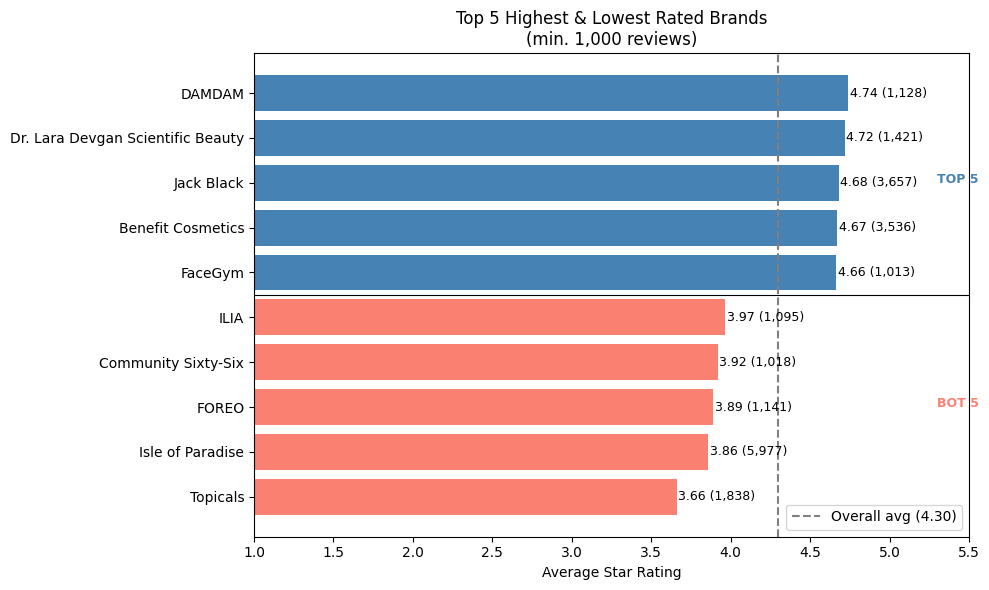

                       brand_name  avg_rating  count    group
                           DAMDAM    4.739362   1128    Top 5
Dr. Lara Devgan Scientific Beauty    4.716397   1421    Top 5
                       Jack Black    4.678425   3657    Top 5
                Benefit Cosmetics    4.668552   3536    Top 5
                          FaceGym    4.663376   1013    Top 5
                             ILIA    3.965297   1095 Bottom 5
              Community Sixty-Six    3.917485   1018 Bottom 5
                            FOREO    3.890447   1141 Bottom 5
                 Isle of Paradise    3.859796   5977 Bottom 5
                         Topicals    3.660501   1838 Bottom 5


In [ ]:
# Min 1000 reviews to avoid small sample bias
brand_rating = (
    review.groupby('brand_name')
    .filter(lambda x: len(x) >= 1000)
    .groupby('brand_name')['rating']
    .agg(avg_rating='mean', count='count')
    .reset_index()
    .sort_values('avg_rating', ascending=False)
)

top5_high = brand_rating.head(5)
top5_low  = brand_rating.tail(5)
top10     = pd.concat([top5_high, top5_low])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue'] * 5 + ['salmon'] * 5

ax.barh(
    top10['brand_name'].astype(str),
    top10['avg_rating'],
    color=colors
)

# Reference line at overall average
overall_avg = review['rating'].mean()
ax.axvline(x=overall_avg, color='gray', linestyle='--',
           label=f'Overall avg ({overall_avg:.2f})')

# Annotate bars
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['avg_rating'] + 0.01, i,
            f"{row['avg_rating']:.2f} ({row['count']:,})",
            va='center', fontsize=9)

ax.set_title('Top 5 Highest & Lowest Rated Brands\n(min. 1,000 reviews)')
ax.set_xlabel('Average Star Rating')
ax.set_xlim(1, 5.5)
ax.invert_yaxis()
ax.legend()

# Add divider between top5 and bottom5
ax.axhline(y=4.5, color='black', linestyle='-', linewidth=0.8)
ax.text(5.3, 2, 'TOP 5', color='steelblue', fontweight='bold', fontsize=9)
ax.text(5.3, 7, 'BOT 5', color='salmon', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print table
print(pd.concat([
    top5_high[['brand_name', 'avg_rating', 'count']].assign(group='Top 5'),
    top5_low[['brand_name', 'avg_rating', 'count']].assign(group='Bottom 5')
]).to_string(index=False))

Key aspect of top 5 brands - what customer love

In [ ]:
# Get top 5 highest rated brands
top5_brands = brand_rating.head(5)['brand_name'].tolist()

# Filter absa_exploded to top 5 brands only
absa_top5 = absa_exploded[absa_exploded['brand_name'].astype(str).isin(top5_brands)]

# Average score per aspect per brand
top5_aspect = (
    absa_top5
    .groupby(['brand_name', 'aspect'])['score']
    .agg(avg_score='mean', count='count')
    .reset_index()
    .sort_values(['brand_name', 'avg_score'], ascending=[True, False])
)

# Top 3 aspects per brand
top3_per_brand = (
    top5_aspect
    .groupby('brand_name')
    .head(3)
    .round(3)
)

print(top3_per_brand.to_string(index=False))

                       brand_name                                      aspect  avg_score  count
                Benefit Cosmetics          universal_service_customer_service      0.721    126
                Benefit Cosmetics       skincare-specific_performance_comfort      0.648    311
                Benefit Cosmetics skincare-specific_performance_effectiveness      0.579   2753
                           DAMDAM       skincare-specific_performance_comfort      0.658    202
                           DAMDAM          universal_service_customer_service      0.628     24
                           DAMDAM        skincare-specific_skin_concern_aging      0.622    114
Dr. Lara Devgan Scientific Beauty       skincare-specific_performance_comfort      0.702     17
Dr. Lara Devgan Scientific Beauty               skincare-specific_finish_look      0.527    240
Dr. Lara Devgan Scientific Beauty          universal_service_customer_service      0.526      7
                          FaceGym       

Key aspect of bottom 5 brands - what customer complain

In [ ]:
# Get top 5 highest rated brands
bot5_brands = brand_rating.tail(5)['brand_name'].tolist()

# Filter absa_exploded to top 5 brands only
absa_bot5 = absa_exploded[absa_exploded['brand_name'].astype(str).isin(bot5_brands)]

# Average score per aspect per brand
bot5_aspect = (
    absa_bot5
    .groupby(['brand_name', 'aspect'])['score']
    .agg(avg_score='mean', count='count')
    .reset_index()
    .sort_values(['brand_name', 'avg_score'], ascending=[False, False])
)

# Top 3 aspects per brand
bot3_per_brand = (
    bot5_aspect
    .groupby('brand_name')
    .tail(3)
    .round(3)
)

print(bot3_per_brand.to_string(index=False))

         brand_name                                   aspect  avg_score  count
           Topicals             skincare-specific_absorption      0.022     44
           Topicals                 universal_price_negative     -0.011    106
           Topicals              universal_packaging_quality     -0.335    120
   Isle of Paradise      skincare-specific_skin_concern_acne      0.028    414
   Isle of Paradise               universal_service_shipping     -0.035    173
   Isle of Paradise              universal_packaging_quality     -0.135    412
               ILIA             skincare-specific_absorption      0.066    216
               ILIA                 universal_price_negative      0.015     72
               ILIA              universal_packaging_quality     -0.032     15
              FOREO                 universal_price_negative      0.104     98
              FOREO               universal_service_shipping      0.055     30
              FOREO              universal_packaging

#Export

In [ ]:
review['review_id'] = range(1, len(review) + 1)

In [ ]:
# Re-explode after adding review id
absa_exploded = review.explode('absa_results').dropna(subset=['absa_results'])
absa_exploded['aspect'] = absa_exploded['absa_results'].apply(lambda x: x['aspect'])
absa_exploded['score']  = absa_exploded['absa_results'].apply(lambda x: x['score'])

In [ ]:
"""
Export ABSA + VADER results to Excel for Tableau.
2 sheets: review_level (1 row = 1 review) + aspect_level (1 row = 1 review × 1 aspect)

HOW TO USE:
- Paste this code into a new cell in your Colab notebook AFTER the ABSA section
- Make sure `review` and `absa_exploded` DataFrames exist
- Run the cell → downloads .xlsx file automatically
"""

import pandas as pd

# SHEET 1: Review-level (overall VADER scores, no aspect info)

review_export_cols = [
    'review_id',          # unique key
    'product_id',
    'product_name',
    'brand_name',
    'tertiary_category',
    'rating',             # ground truth star rating
    'rating_label',       # positive/neutral/negative
    'vader_compound',     # VADER body score
    'vader_label',        # VADER predicted label
    'title_compound',     # VADER title score
    'title_label',
    'review_length_words',
    'submission_time',
]


df_review_level = review[review_export_cols].copy()

# Convert category dtype to string (Tableau doesn't like pandas Categorical)
for col in df_review_level.select_dtypes(include='category').columns:
    df_review_level[col] = df_review_level[col].astype(str)

print(f"Sheet 1 — review_level: {df_review_level.shape}")

# SHEET 2: Aspect-level (1 row = 1 review × 1 aspect match)
aspect_export_cols = [
    'review_id',
    'product_id',
    'product_name',
    'brand_name',
    'tertiary_category',
    'rating',
    'rating_label',
    'aspect',             # matched aspect (e.g., hydration_moisture)
    'score',              # VADER score for the sentence that matched
    'submission_time']

df_aspect_level = absa_exploded[aspect_export_cols].copy()

# Convert category dtype to string
for col in df_aspect_level.select_dtypes(include='category').columns:
    df_aspect_level[col] = df_aspect_level[col].astype(str)

# Split aspect into main_aspect + sub_aspect for easier Tableau filtering
# e.g., "hydration_moisture" → main="hydration", sub="moisture"
df_aspect_level['main_aspect'] = df_aspect_level['aspect'].apply(
    lambda x: x.split('_')[0] if '_' in str(x) else str(x)
)
df_aspect_level['sub_aspect'] = df_aspect_level['aspect'].apply(
    lambda x: '_'.join(x.split('_')[1:]) if '_' in str(x) else ''
)

# Add sentiment label for aspect score
df_aspect_level['aspect_sentiment_label'] = df_aspect_level['score'].apply(
    lambda s: 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
)

print(f"Sheet 2 — aspect_level: {df_aspect_level.shape}")


# EXPORT TO CSV
df_review_level.to_csv(BASE_PATH + 'review_level.csv', index=False)
df_aspect_level.to_csv(BASE_PATH + 'aspect_level.csv', index=False)

from google.colab import files
files.download(BASE_PATH + 'review_level.csv')
files.download(BASE_PATH + 'aspect_level.csv')

print(f"\nExported to: {OUTPUT_PATH}")
print(f"  review_level : {len(df_review_level):,} rows × {len(df_review_level.columns)} cols")
print(f"  aspect_level : {len(df_aspect_level):,} rows × {len(df_aspect_level.columns)} cols")

# Auto-download in Colab
from google.colab import files
files.download(OUTPUT_PATH)

Sheet 1 — review_level: (1092967, 13)
Sheet 2 — aspect_level: (4051034, 13)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NameError: name 'OUTPUT_PATH' is not defined